# Calibration Quality and Sensor Drift Analysis

This notebook analyzes the quality of calibration recordings (verifying user stillness) and tracks the consistency of sensor drift (zero-bias offsets) over time for both IMU1 (Wrist) and IMU2 (Finger).

Specifically, it addresses:
1. **Stillness Auditing:** Identifies and flags poor-quality calibrations where the user did not hold still (exceeding standard deviation thresholds).
2. **Drift Consistency Analysis:** Tracks zero-bias offsets over consecutive calibrations within the same recording session to understand how fast the sensor drift changes, helping to inform live-calibration strategies.

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Resolve paths
PROJECT_ROOT = Path("__file__").resolve().parents[1]
sys.path.append(str(PROJECT_ROOT / "src"))

try:
    from data_fusion_project.core.paths import DATA_DIR
except ImportError:
    DATA_DIR = PROJECT_ROOT / "data"

print(f"Data directory: {DATA_DIR}")

Data directory: /Users/jantischner/Library/CloudStorage/OneDrive-Personal/TH_OHM_B.Sc.Inf/Th-Ohm_B.Sc.Inf_Sem6/DatFus_Sem6_Axenie/DataFusionProject/data


In [2]:
# Constants and Thresholds for Quality Auditing
# Stillness is audited by checking standard deviation of signals during calibration.
# High standard deviation indicates sensor movement (not holding still).
THRESHOLD_ACC_STD = 0.025  # g-force standard deviation threshold
THRESHOLD_GYR_STD = 3.     # dps (degrees per second) standard deviation threshold

In [3]:
def parse_calibration_filename(filename):
    """
    Parses the sample count from the calibration filename.
    calibration.csv -> sample_count = 0
    calibration_20.csv -> sample_count = 20
    """
    stem = Path(filename).stem
    if stem == "calibration":
        return 0
    parts = stem.split("_")
    if len(parts) >= 2 and parts[1].isdigit():
        return int(parts[1])
    return 0

# Scan data directory for calibration files
cal_files = sorted(list(DATA_DIR.glob("**/calibration*.csv")))
cal_records = []

for f in cal_files:
    # Get session details from path structure: DATA_DIR / gesture / session / file
    relative = f.relative_to(DATA_DIR)
    parts = relative.parts
    if len(parts) < 3:
        continue
        
    gesture = parts[0]
    session = parts[1]
    name = parts[2]
    
    # Skip temporary files
    if f.name == "calibration.png":
        continue
        
    # Load recording_session.json if exists to get exact sample index
    meta_path = f.parent / "recording_session.json"
    sample_count = None
    if meta_path.exists():
        try:
            with open(meta_path, "r") as json_f:
                import json
                meta = json.load(json_f)
                for entry in meta.get("recalibrations", []):
                    if entry["file"] == f.name:
                        sample_count = entry["sample_index"]
                        break
        except Exception:
            pass
    if sample_count is None:
        sample_count = parse_calibration_filename(f.name)

    cal_records.append({
        'path': f,
        'gesture': gesture,
        'session': session,
        'filename': f.name,
        'sample_count': sample_count
    })

print(f"Found {len(cal_records)} calibration records across data directories.")


Found 3 calibration records across data directories.


In [4]:
# Audit stillness quality
audited_records = []
poor_calibrations = []

for rec in cal_records:
    try:
        df = pd.read_csv(rec['path'])
        
        # Calculate standard deviation for gyroscope and accelerometer channels
        imu1_acc_std = df[['IMU1_accX', 'IMU1_accY', 'IMU1_accZ']].std().max()
        imu1_gyr_std = df[['IMU1_gyrX', 'IMU1_gyrY', 'IMU1_gyrZ']].std().max()
        imu2_acc_std = df[['IMU2_accX', 'IMU2_accY', 'IMU2_accZ']].std().max()
        imu2_gyr_std = df[['IMU2_gyrX', 'IMU2_gyrY', 'IMU2_gyrZ']].std().max()
        
        # Calculate mean zero-biases (drift offsets)
        imu1_bias = {
            'X': df['IMU1_gyrX'].mean(),
            'Y': df['IMU1_gyrY'].mean(),
            'Z': df['IMU1_gyrZ'].mean()
        }
        imu2_bias = {
            'X': df['IMU2_gyrX'].mean(),
            'Y': df['IMU2_gyrY'].mean(),
            'Z': df['IMU2_gyrZ'].mean()
        }
        
        # Check if thresholds are violated
        failed = False
        reasons = []
        if imu1_acc_std > THRESHOLD_ACC_STD:
            failed = True
            reasons.append(f"IMU1 Acc STD ({imu1_acc_std:.4f}g) > {THRESHOLD_ACC_STD}g")
        if imu1_gyr_std > THRESHOLD_GYR_STD:
            failed = True
            reasons.append(f"IMU1 Gyr STD ({imu1_gyr_std:.2f} dps) > {THRESHOLD_GYR_STD} dps")
        if imu2_acc_std > THRESHOLD_ACC_STD:
            failed = True
            reasons.append(f"IMU2 Acc STD ({imu2_acc_std:.4f}g) > {THRESHOLD_ACC_STD}g")
        if imu2_gyr_std > THRESHOLD_GYR_STD:
            failed = True
            reasons.append(f"IMU2 Gyr STD ({imu2_gyr_std:.2f} dps) > {THRESHOLD_GYR_STD} dps")
            
        rec_data = {
            **rec,
            'imu1_acc_std': imu1_acc_std,
            'imu1_gyr_std': imu1_gyr_std,
            'imu2_acc_std': imu2_acc_std,
            'imu2_gyr_std': imu2_gyr_std,
            'imu1_bias': imu1_bias,
            'imu2_bias': imu2_bias,
            'failed_stillness': failed,
            'reasons': reasons
        }
        audited_records.append(rec_data)
        
        if failed:
            poor_calibrations.append(rec_data)
            
    except Exception as e:
        print(f"Error auditing {rec['filename']} in session {rec['session']}: {e}")

print(f"Audited {len(audited_records)} files.")
print(f"Flagged {len(poor_calibrations)} poor-quality calibrations (user movement detected).")

if poor_calibrations:
    print("\n--- FLAGGED CALIBRATIONS ---")
    for pc in poor_calibrations:
        print(f"Gesture: {pc['gesture']}, Session: {pc['session']}, File: {pc['filename']}")
        print(f"  Reasons: {', '.join(pc['reasons'])}")

Audited 3 files.
Flagged 1 poor-quality calibrations (user movement detected).

--- FLAGGED CALIBRATIONS ---
Gesture: swipe_right, Session: session_1782576697, File: calibration_2.csv
  Reasons: IMU2 Gyr STD (3.19 dps) > 3.0 dps


## Drift Analysis for Multi-Calibration Sessions

Here, we identify sessions that have multiple calibrations (because the session duration exceeded `MAX_SAMPLES_BEFORE_RECALIBRATION` samples, triggering periodic calibration). We analyze zero-bias trends and calculate the drift rate over the course of the session.

In [5]:
# Group audited records by (gesture, session)
sessions_dict = {}
for r in audited_records:
    key = (r['gesture'], r['session'])
    if key not in sessions_dict:
        sessions_dict[key] = []
    sessions_dict[key].append(r)

# Filter sessions that have multiple calibrations
multi_cal_sessions = {k: sorted(v, key=lambda x: x['sample_count']) for k, v in sessions_dict.items() if len(v) > 1}

print(f"Found {len(multi_cal_sessions)} sessions with multiple calibrations for drift rate tracking.")

for (gesture, session), records in multi_cal_sessions.items():
    print(f"\n======================================================================")
    print(f"Session: {gesture}/{session} ({len(records)} calibrations)")
    print(f"======================================================================")
    
    prev_rec = None
    for i, r in enumerate(records):
        print(f"\nCalibration at sample {r['sample_count']} ({r['filename']}):")
        print(f"  IMU1 (Wrist) Gyro Bias: X={r['imu1_bias']['X']:.3f}, Y={r['imu1_bias']['Y']:.3f}, Z={r['imu1_bias']['Z']:.3f} dps")
        print(f"  IMU2 (Finger) Gyro Bias: X={r['imu2_bias']['X']:.3f}, Y={r['imu2_bias']['Y']:.3f}, Z={r['imu2_bias']['Z']:.3f} dps")
        
        if prev_rec is not None:
            # Calculate change in bias
            step_diff = r['sample_count'] - prev_rec['sample_count']
            
            # IMU1 Bias Changes
            imu1_diff = {axis: r['imu1_bias'][axis] - prev_rec['imu1_bias'][axis] for axis in ['X', 'Y', 'Z']}
            imu1_dist = np.sqrt(sum(d**2 for d in imu1_diff.values()))
            
            # IMU2 Bias Changes
            imu2_diff = {axis: r['imu2_bias'][axis] - prev_rec['imu2_bias'][axis] for axis in ['X', 'Y', 'Z']}
            imu2_dist = np.sqrt(sum(d**2 for d in imu2_diff.values()))
            
            print(f"  -> Drift since sample {prev_rec['sample_count']} (diff: {step_diff} samples):")
            print(f"     IMU1 Bias shift magnitude: {imu1_dist:.4f} dps (rate: {imu1_dist/step_diff:.6f} dps/sample)")
            print(f"     IMU2 Bias shift magnitude: {imu2_dist:.4f} dps (rate: {imu2_dist/step_diff:.6f} dps/sample)")
            
        prev_rec = r

Found 1 sessions with multiple calibrations for drift rate tracking.

Session: swipe_right/session_1782576697 (3 calibrations)

Calibration at sample 0 (calibration_0.csv):
  IMU1 (Wrist) Gyro Bias: X=3.498, Y=-0.488, Z=0.511 dps
  IMU2 (Finger) Gyro Bias: X=1.448, Y=-0.197, Z=-0.421 dps

Calibration at sample 25 (calibration_1.csv):
  IMU1 (Wrist) Gyro Bias: X=3.659, Y=-0.520, Z=0.691 dps
  IMU2 (Finger) Gyro Bias: X=1.587, Y=-0.309, Z=-0.276 dps
  -> Drift since sample 0 (diff: 25 samples):
     IMU1 Bias shift magnitude: 0.2435 dps (rate: 0.009739 dps/sample)
     IMU2 Bias shift magnitude: 0.2299 dps (rate: 0.009195 dps/sample)

Calibration at sample 50 (calibration_2.csv):
  IMU1 (Wrist) Gyro Bias: X=3.560, Y=-0.822, Z=0.606 dps
  IMU2 (Finger) Gyro Bias: X=1.599, Y=-0.302, Z=-0.298 dps
  -> Drift since sample 25 (diff: 25 samples):
     IMU1 Bias shift magnitude: 0.3288 dps (rate: 0.013153 dps/sample)
     IMU2 Bias shift magnitude: 0.0259 dps (rate: 0.001037 dps/sample)


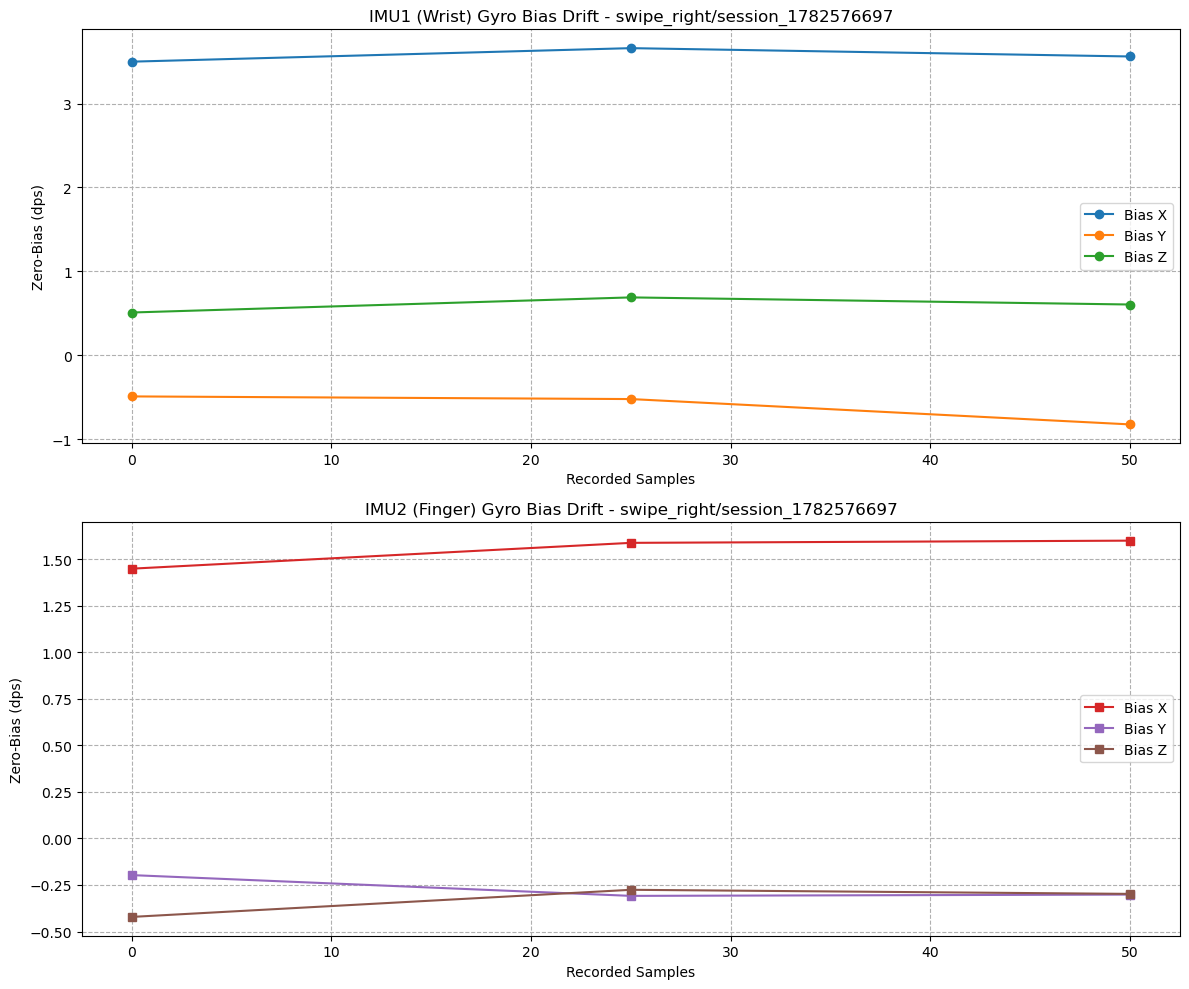

In [6]:
# Plot drift curves for multi-calibration sessions
if multi_cal_sessions:
    fig, axs = plt.subplots(len(multi_cal_sessions) * 2, 1, figsize=(12, 5 * len(multi_cal_sessions) * 2), sharex=False)
    if isinstance(axs, np.ndarray):
        axs = axs.flatten()
    else:
        axs = np.array([axs])
        
    plot_idx = 0
    for (gesture, session), records in multi_cal_sessions.items():
        sample_counts = [r['sample_count'] for r in records]
        
        # IMU1 Biases
        imu1_x = [r['imu1_bias']['X'] for r in records]
        imu1_y = [r['imu1_bias']['Y'] for r in records]
        imu1_z = [r['imu1_bias']['Z'] for r in records]
        
        # Plot IMU1
        ax = axs[plot_idx]
        ax.plot(sample_counts, imu1_x, 'o-', label='Bias X', color='#1f77b4')
        ax.plot(sample_counts, imu1_y, 'o-', label='Bias Y', color='#ff7f0e')
        ax.plot(sample_counts, imu1_z, 'o-', label='Bias Z', color='#2ca02c')
        ax.set_title(f"IMU1 (Wrist) Gyro Bias Drift - {gesture}/{session}")
        ax.set_xlabel("Recorded Samples")
        ax.set_ylabel("Zero-Bias (dps)")
        ax.grid(True, linestyle='--')
        ax.legend()
        plot_idx += 1
        
        # IMU2 Biases
        imu2_x = [r['imu2_bias']['X'] for r in records]
        imu2_y = [r['imu2_bias']['Y'] for r in records]
        imu2_z = [r['imu2_bias']['Z'] for r in records]
        
        # Plot IMU2
        ax = axs[plot_idx]
        ax.plot(sample_counts, imu2_x, 's-', label='Bias X', color='#d62728')
        ax.plot(sample_counts, imu2_y, 's-', label='Bias Y', color='#9467bd')
        ax.plot(sample_counts, imu2_z, 's-', label='Bias Z', color='#8c564b')
        ax.set_title(f"IMU2 (Finger) Gyro Bias Drift - {gesture}/{session}")
        ax.set_xlabel("Recorded Samples")
        ax.set_ylabel("Zero-Bias (dps)")
        ax.grid(True, linestyle='--')
        ax.legend()
        plot_idx += 1
        
    plt.tight_layout()
    plt.show()
else:
    print("No multi-calibration sessions found to plot.")